In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df = pd.read_csv("Mental_Distress_Dataset-original.csv")

In [ ]:
print(df.head(10100))

                                                    text     label
0      I have been (passively at best, actively at wo...  Suicidal
1      Idk when or how but soon. I will likely hang m...  Suicidal
2      I used to say that I would not commit suicide ...  Suicidal
3      Just so I can work minimum wage for 40 years w...  Suicidal
4      for a little while, i did everything right. i ...  Suicidal
...                                                  ...       ...
10095  Apparently Taylor Swift likes Shakespeare. She...    Others
10096  The demon king slowly popping up in the backgr...    Others
10097  I like how soulless and fake they look when th...    Others
10098  At first, I didn't know what to write, but now...    Others
10099  This is the end of the dataset. It is good tha...    Others

[10100 rows x 2 columns]


In [ ]:
df.columns

Index(['text', 'label'], dtype='object')

In [ ]:
# unique()- to retrieve the unique labels. without it, it'll print all labels with duplicates

print(df['label'].unique())

['Suicidal' 'Anxious' 'Frustrated' 'Depressed' 'Others']


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10100 entries, 0 to 10099
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    10098 non-null  object
 1   label   10100 non-null  object
dtypes: object(2)
memory usage: 157.9+ KB


In [ ]:
# isnull()- if a cell is null, return True, otherwise False. In this segment we will care about the TRUE ones
# sum()- returns the number of TRUEs/missing values per column

missing = df.isnull().sum()

print("Missing values per column:")
print(missing)

Missing values per column:
text     2
label    0
dtype: int64


In [ ]:
null_rows = df[df.isnull().any(axis=1)]
display(null_rows)

,text,label
1767,NaN,Suicidal
6994,NaN,Depressed


In [ ]:
df_new = df.dropna(subset=['text']).copy()
# print(f"Created df_new with {len(df_new)} rows")

In [ ]:
print(df_new.head(10100))
print("Rows with missing text dropped.")

                                                    text     label
0      I have been (passively at best, actively at wo...  Suicidal
1      Idk when or how but soon. I will likely hang m...  Suicidal
2      I used to say that I would not commit suicide ...  Suicidal
3      Just so I can work minimum wage for 40 years w...  Suicidal
4      for a little while, i did everything right. i ...  Suicidal
...                                                  ...       ...
10095  Apparently Taylor Swift likes Shakespeare. She...    Others
10096  The demon king slowly popping up in the backgr...    Others
10097  I like how soulless and fake they look when th...    Others
10098  At first, I didn't know what to write, but now...    Others
10099  This is the end of the dataset. It is good tha...    Others

[10098 rows x 2 columns]
Rows with missing text dropped.


In [ ]:
print(df.shape)
print(df_new.shape) # 2 NaN value rows were dropped

(10100, 2)
(10098, 2)


In [ ]:
# df_new has been created in the previous step.
print(f"df_new now contains {len(df_new)} rows after dropping nulls, while original df has {len(df)} rows.")

df_new now contains 10098 rows after dropping nulls, while original df has 10100 rows.


In [ ]:
df_new.to_csv('Mental_Distress_Dataset_updated.csv', index=False)
print("Updated dataset saved as 'Mental_Distress_Dataset_updated.csv'")

Updated dataset saved as 'Mental_Distress_Dataset_updated.csv'


In [ ]:
label_counts = df_new['label'].value_counts()
print(label_counts)

label
Suicidal      2170
Frustrated    2062
Depressed     2050
Anxious       2038
Others        1778
Name: count, dtype: int64


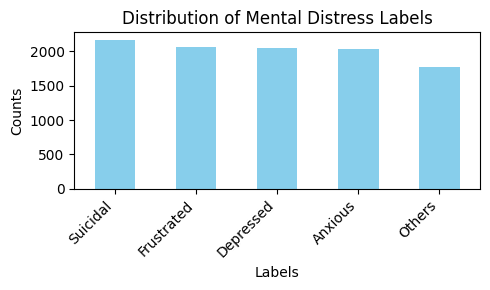

In [ ]:
# Create a bar chart
plt.figure(figsize=(5, 3))
label_counts.plot(kind='bar', color='skyblue')
plt.title('Distribution of Mental Distress Labels')
plt.xlabel('Labels')
plt.ylabel('Counts')
plt.xticks(rotation=45, ha='right')

plt.tight_layout()
plt.show()